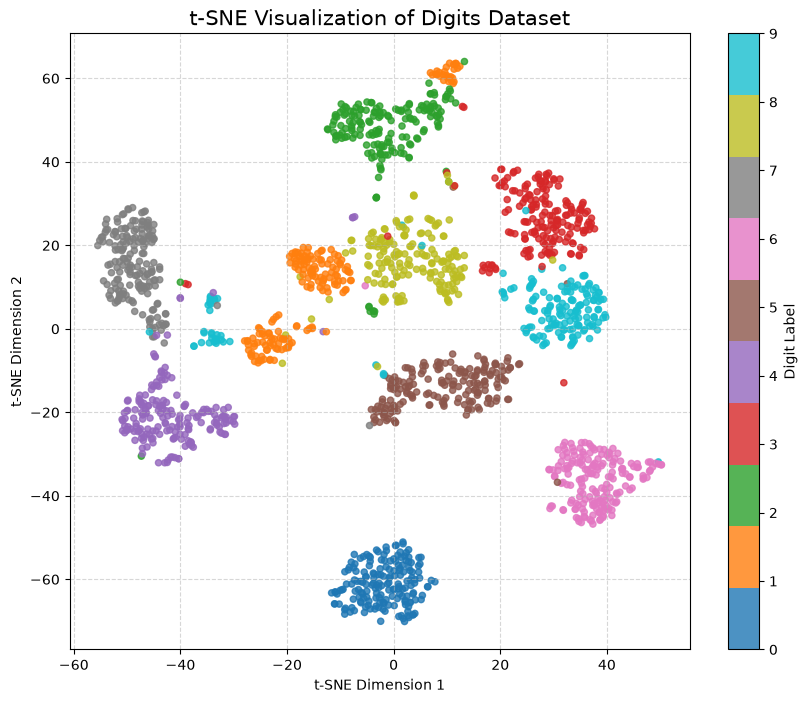

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE



# 不需要传入 n_iter，直接使用默认的迭代次数（默认为1000）
X_tsne = tsne.fit_transform(X_scaled)

# ================= 1. 数据准备 =================
# 加载高维数据集（以_digits数据集为例，64维）
digits = datasets.load_digits()
X = digits.data
y = digits.target

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================= 2. PCA 预降维 (可选但推荐) =================
# 如果维度>50，先用PCA降至50维，去噪并加速
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)
# 如果维度本身就低于50，可以直接使用 X_scaled

# ================= 3. t-SNE 降维 =================
# 设置 random_state 保证结果可复现

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,          # 不用 'auto'，写一个具体数值（默认就是200）
    random_state=42,
    init='random'
)
# 不需要传入 n_iter，直接使用默认的迭代次数（默认为1000）
X_tsne = tsne.fit_transform(X_scaled)

# 执行降维（输入PCA处理后的数据）
X_tsne = tsne.fit_transform(X_pca) 

# ================= 4. 结果可视化 =================
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_tsne[:, 0], 
    X_tsne[:, 1], 
    c=y,               # 根据标签上色
    cmap='tab10',      # 颜色映射
    s=20,              # 点的大小
    alpha=0.8          # 透明度
)

plt.title("t-SNE Visualization of Digits Dataset", fontsize=15)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(scatter, label='Digit Label')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import time

def main():
    # ==========================================
    # 1. 加载 MNIST 数据集
    # ==========================================
    print("正在下载/加载 MNIST 数据集 (首次运行需要下载，请耐心等待)...")
    # fetch_openml 会自动缓存数据到本地
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X, y = mnist["data"], mnist["target"]
    
    # 将标签转换为字符串类型，以便 Plotly 将其识别为离散类别（分配10种不同颜色）
    y = y.astype(str) 
    print(f"数据集加载完成！总样本数: {X.shape[0]}, 特征维度: {X.shape[1]}")

    # ==========================================
    # 2. 数据采样 (为了演示速度)
    # ==========================================
    # 完整 70000 张图跑 t-SNE 极慢，这里随机采样 5000 张进行可视化
    SAMPLE_SIZE = 5000
    np.random.seed(42) # 保证每次采样的结果一致
    indices = np.random.choice(X.shape[0], SAMPLE_SIZE, replace=False)
    X_sampled = X[indices]
    y_sampled = y[indices]
    print(f"已随机采样 {SAMPLE_SIZE} 个样本用于降维和可视化。")

    # 数据归一化 (将像素值 0-255 缩放到 0-1 之间)
    X_sampled = X_sampled / 255.0

    # ==========================================
    # 3. PCA 预降维 (加速 t-SNE 并去噪)
    # ==========================================
    print("正在进行 PCA 降维 (784维 -> 50维)...")
    pca = PCA(n_components=50, random_state=42)
    X_pca = pca.fit_transform(X_sampled)
    print(f"PCA 完成，保留了 {np.sum(pca.explained_variance_ratio_):.2%} 的方差信息。")

    # ==========================================
    # 4. t-SNE 3D 降维
    # ==========================================
    print("正在进行 t-SNE 3D 降维 (这可能需要 1~3 分钟，取决于您的 CPU)...")
    start_time = time.time()
    
    # 初始化 t-SNE，设置 n_components=3
    tsne = TSNE(
        n_components=3, 
        perplexity=30,      # 通常设置在 5~50 之间，30 是默认且稳健的值
        learning_rate='auto', # 自动调整学习率
        init='pca',         # 使用 PCA 结果初始化，更稳定
        random_state=42,
        n_jobs=-1           # 使用所有可用 CPU 核心加速
    )
    X_tsne_3d = tsne.fit_transform(X_pca)
    
    end_time = time.time()
    print(f"t-SNE 降维完成！耗时: {end_time - start_time:.2f} 秒")

    # ==========================================
    # 5. Plotly 交互式 3D 可视化
    # ==========================================
    print("正在生成 3D 交互式散点图...")
    
    # 构建 DataFrame 方便 Plotly 读取
    df = pd.DataFrame({
        't-SNE 1': X_tsne_3d[:, 0],
        't-SNE 2': X_tsne_3d[:, 1],
        't-SNE 3': X_tsne_3d[:, 2],
        'Digit': y_sampled
    })

    # 使用 Plotly Express 绘制 3D 散点图
    fig = px.scatter_3d(
        df, 
        x='t-SNE 1', 
        y='t-SNE 2', 
        z='t-SNE 3',
        color='Digit',             # 按数字标签分配 10 种颜色
        labels={'Digit': '数字类别'},
        title=f't-SNE 3D Visualization of MNIST (N={SAMPLE_SIZE})',
        opacity=0.8,               # 设置透明度，防止中心的点被完全遮挡
        category_orders={'Digit': ['0','1','2','3','4','5','6','7','8','9']} # 固定颜色顺序
    )

    # 优化图表布局
    fig.update_traces(marker=dict(size=3)) # 调整点的大小
    fig.update_layout(
        legend_title_text='Digits',
        scene=dict(
            xaxis_title='t-SNE Dimension 1',
            yaxis_title='t-SNE Dimension 2',
            zaxis_title='t-SNE Dimension 3'
        ),
        width=1000,
        height=800
    )

    # 显示交互式图表 (在 Jupyter Notebook 中会直接内嵌，在脚本中会打开浏览器)
    fig.show()
    
    # 可选：保存为 HTML 文件，方便分享给他人查看
    # fig.write_html("mnist_tsne_3d.html")
    # print("图表已保存为 mnist_tsne_3d.html")

if __name__ == "__main__":
    main()

正在下载/加载 MNIST 数据集 (首次运行需要下载，请耐心等待)...
数据集加载完成！总样本数: 70000, 特征维度: 784
已随机采样 5000 个样本用于降维和可视化。
正在进行 PCA 降维 (784维 -> 50维)...
PCA 完成，保留了 82.74% 的方差信息。
正在进行 t-SNE 3D 降维 (这可能需要 1~3 分钟，取决于您的 CPU)...
t-SNE 降维完成！耗时: 13.27 秒
正在生成 3D 交互式散点图...
